In [1]:
import pathlib

import pandas as pd
import numpy as np
import torch

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout
from highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod


/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "artifacts/explainability_method_tester/20260429_221014/MoleculeGDetector/positive_explainability_results.csv")

df = df[df["Integrated Gradients_auroc"] != 1.0]
df = df.dropna(subset=["Integrated Gradients_auroc"])

suspicious_smiles = df["SMILES"].tolist()

suspicious_without_nitrogen_ion = [smiles if "N+" not in smiles else None for smiles in suspicious_smiles]
suspicious_without_nitrogen_ion = [smiles for smiles in suspicious_without_nitrogen_ion if smiles is not None]

In [3]:
model = MoleculeGDetector()

example_suspicious_smile = suspicious_smiles[0]

mol = Chem.MolFromSmiles(example_suspicious_smile)
mol = Chem.RemoveAllHs(mol)
x, edge_index, edge_features = mol_to_torch(mol)

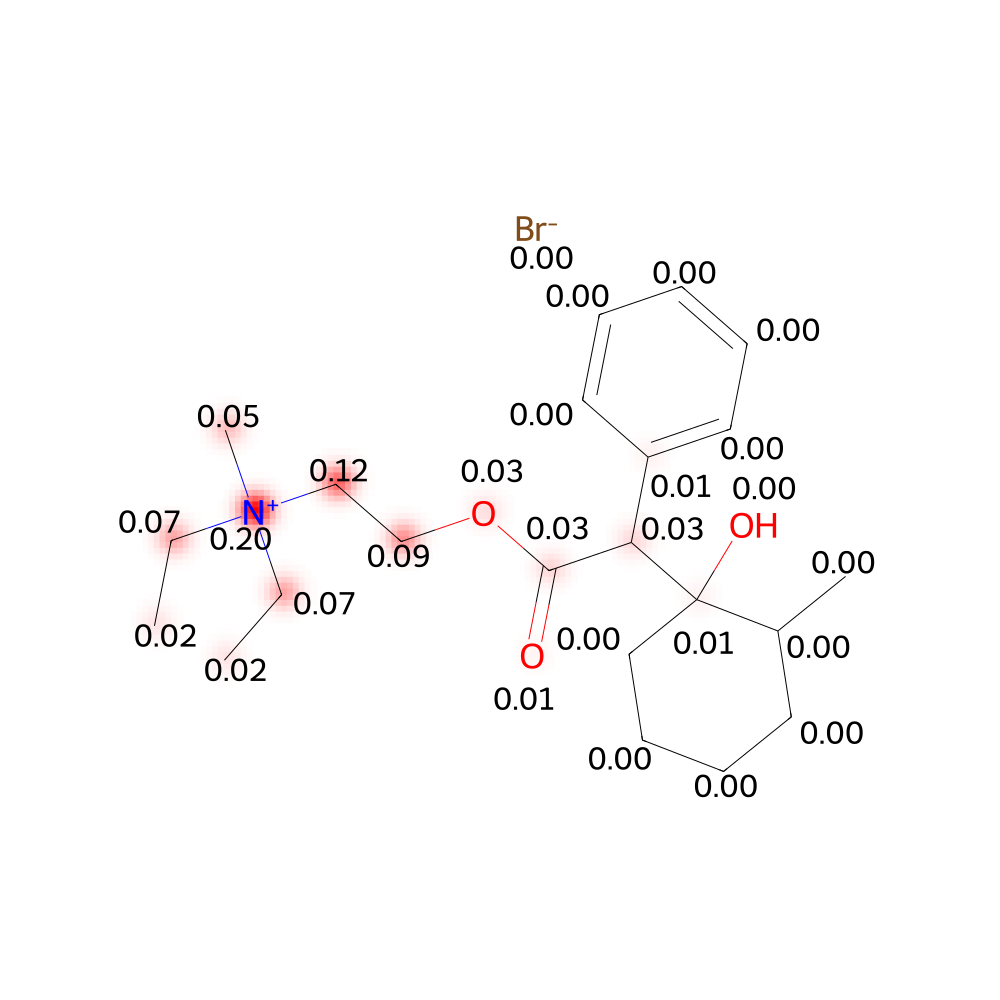

In [4]:
smarts_post = name_to_post_smarts["MoleculeGDetector"]

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)

img

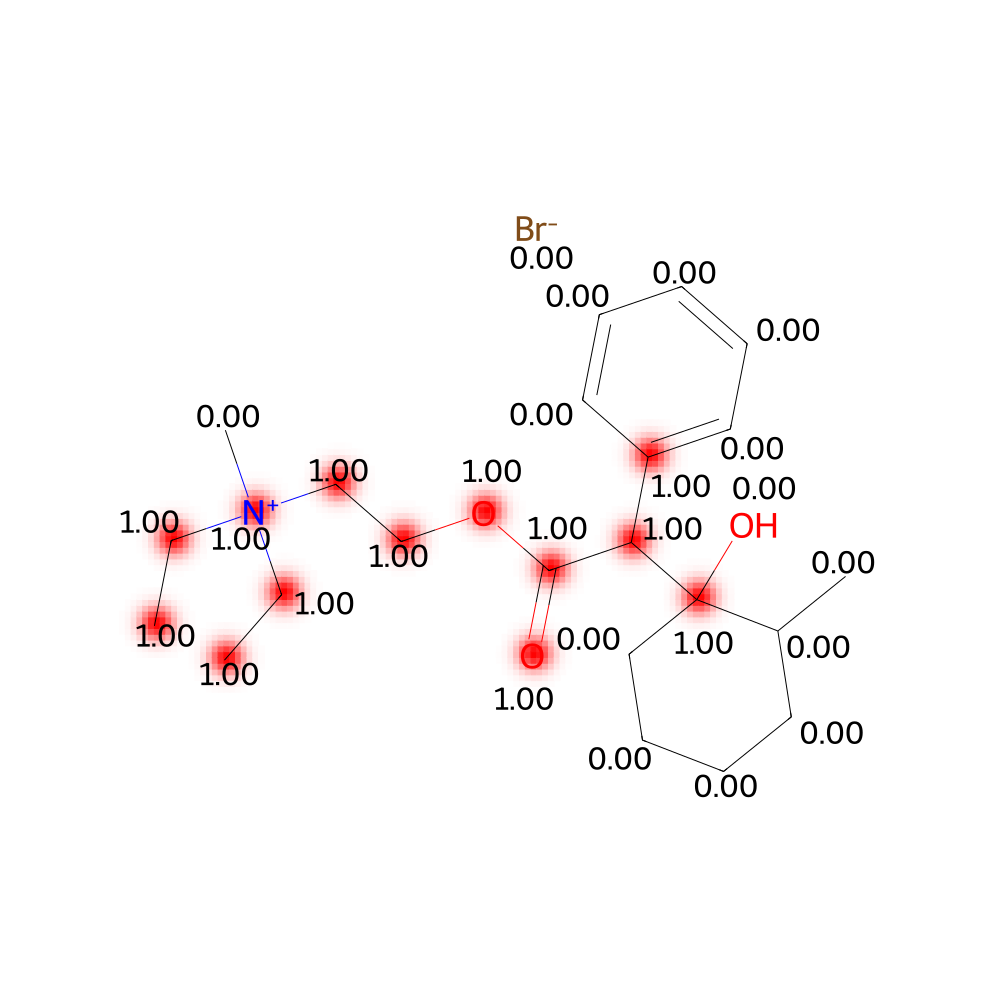

In [5]:
baseline_img = visualize_smarts_match(
    mol,
    smarts_post,
)

baseline_img


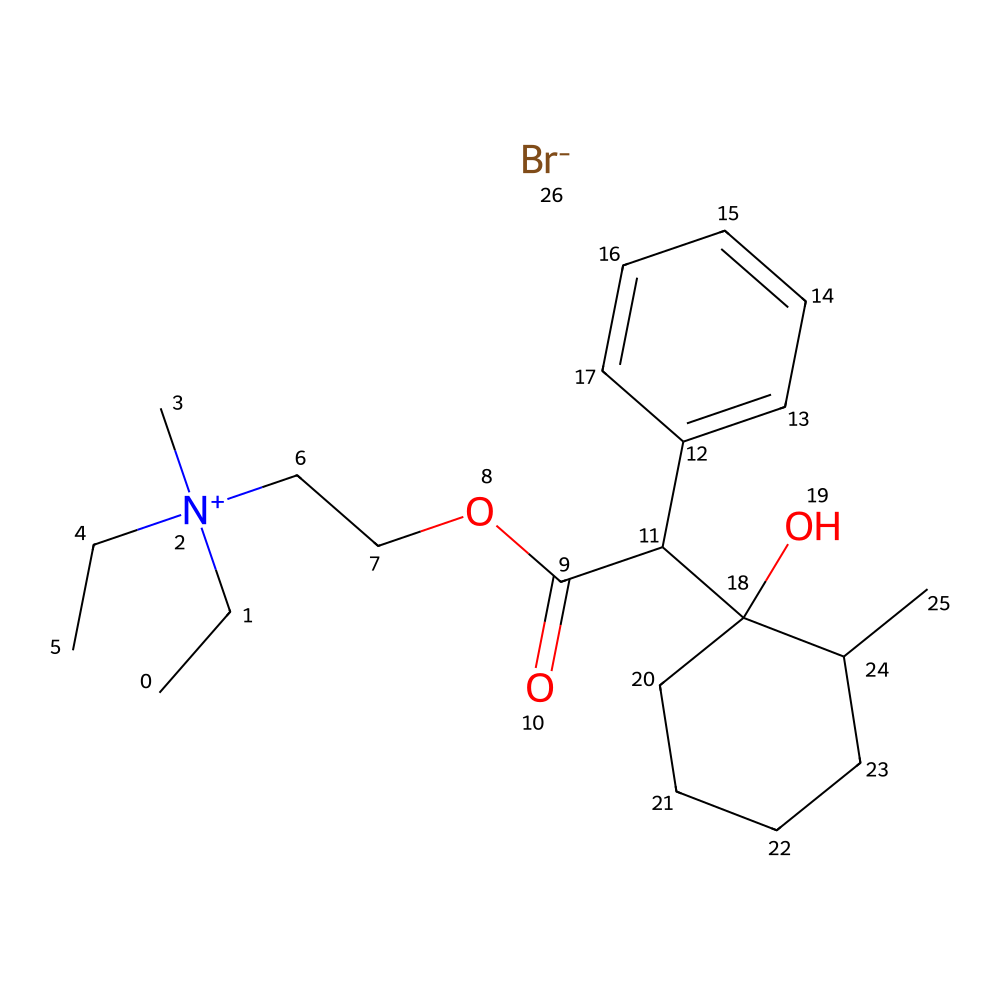

In [6]:
# How does prediction of model change w.r.t to that weird carbon atom?
from rdkit.Chem import Draw

for atom in mol.GetAtoms():
    atom.SetProp('atomNote', f"{atom.GetIdx()}")

Draw.MolToImage(mol, size=(1000, 1000))

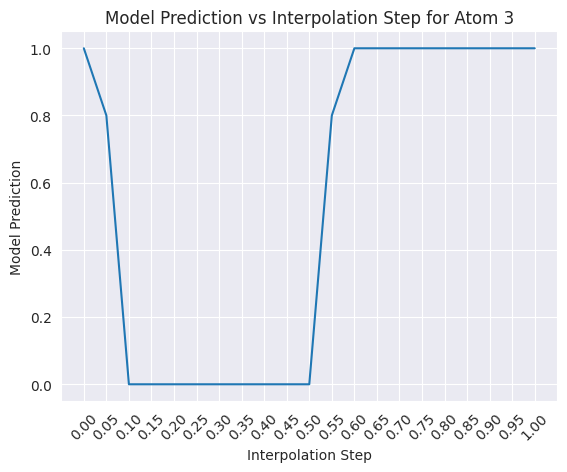

In [9]:
#x, edge_index, edge_features = mol_to_torch(mol)

model.readout = AllNonZeroReadout()

x_zerod_third_atom = x.clone()

x_zerod_third_atom[3][6] = 0.0  # Zero out the "carbon" feature

diff = x - x_zerod_third_atom

num_steps = 20

increment = diff / num_steps

scalar_increment = 1 / num_steps

xlabels = []

predictions = []

for step in range(num_steps + 1):
    xlabels.append(scalar_increment * step)

    interpolated_x = x_zerod_third_atom + increment * step

    with torch.no_grad():
        pred = model(interpolated_x, edge_features, edge_index)

        predictions.append(pred.item())

plt.plot(predictions)
xlabels = [f"{label:.2f}" for label in xlabels]
# set xticks to be the value of the third atom's features at each step

plt.xticks(ticks=range(num_steps + 1), labels=xlabels, rotation=45)

plt.xlabel("Interpolation Step")

plt.ylabel("Model Prediction")

plt.title("Model Prediction vs Interpolation Step for Atom 3")

plt.show()

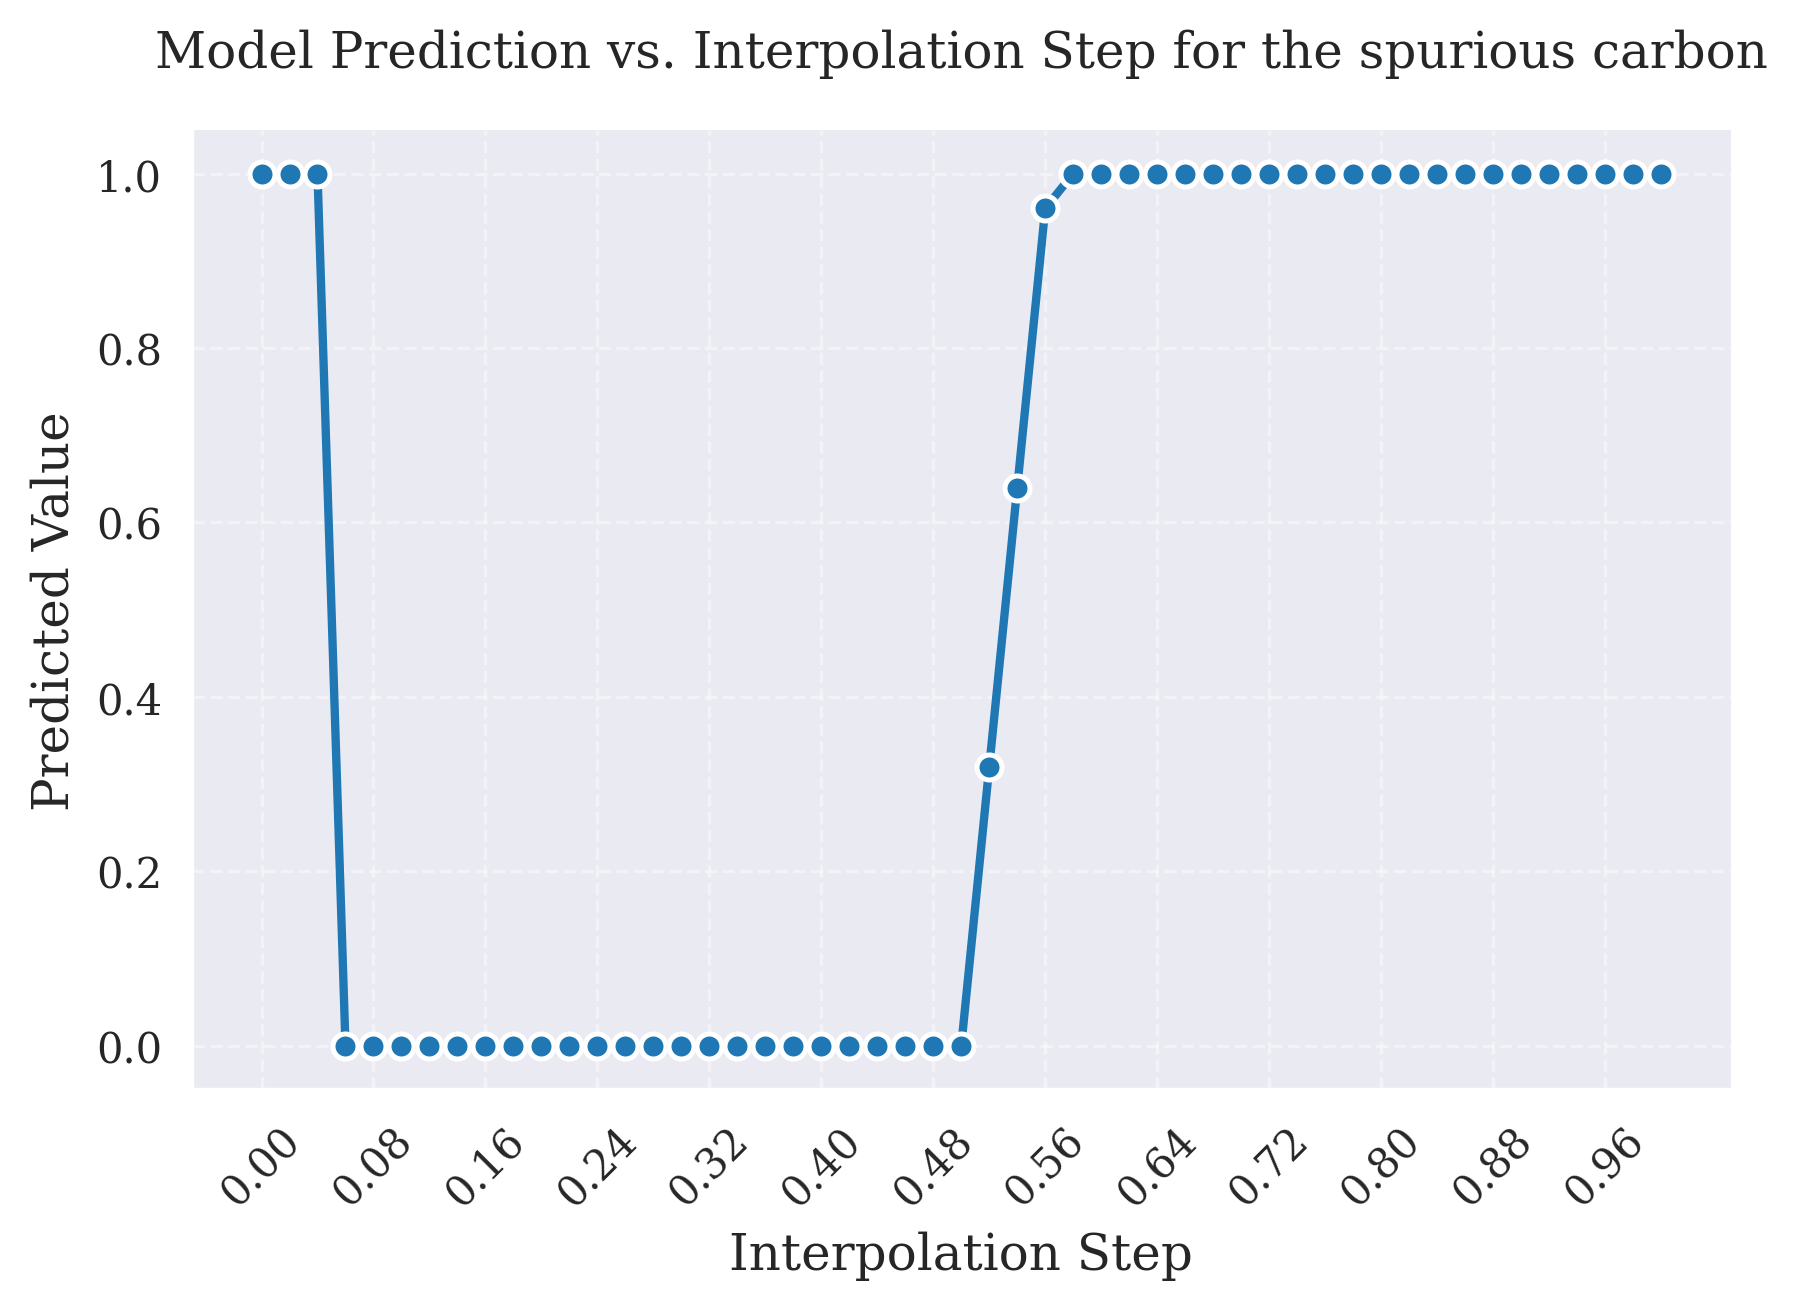

In [10]:
# This code for chart was styled with use of LLM; however, I've verified that it aligns with what I've done myself. (see cell above)

import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Publication-Ready Global Formatting
# ---------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (6, 4.5),  # Standard single-column size
    "figure.dpi": 300,  # High resolution for rendering
    "font.family": "serif",  # Typical academic font style
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,  # Readable base font size
    "axes.labelsize": 12,  # Slightly larger axis labels
    "axes.titlesize": 12,  # Title size
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,  # Thicker, bolder lines
    "lines.markersize": 6,  # Visible data points
    "axes.grid": True,  # Add grid for readability
    "grid.alpha": 0.4,  # Make grid unobtrusive
    "grid.linestyle": "--"  # Dashed grid lines
})

# [Assume mol_to_torch and model setup here]
# x, edge_index, edge_features = mol_to_torch(mol)
# model.readout = AllNonZeroReadout()

x_zerod_third_atom = x.clone()
x_zerod_third_atom[3][6] = 0.0  # Zero out the "carbon" feature

diff = x - x_zerod_third_atom

num_steps = 50
increment = diff / num_steps
scalar_increment = 1 / num_steps

xlabels = []
predictions = []

for step in range(num_steps + 1):
    xlabels.append(scalar_increment * step)
    interpolated_x = x_zerod_third_atom + increment * step
    with torch.no_grad():
        pred = model(interpolated_x, edge_features, edge_index)
        predictions.append(pred.item())

# ---------------------------------------------------------
# 2. Object-Oriented Plotting
# ---------------------------------------------------------
fig, ax = plt.subplots()

# Use a marker to explicitly show the discrete interpolation steps
ax.plot(range(num_steps + 1), predictions, color="#1f77b4", marker="o",
        markeredgecolor="white", markeredgewidth=1.2, label="Model Prediction")

# Format labels to 2 decimal places
xlabels_str = [f"{label:.2f}" for label in xlabels]

# To prevent crowding, optionally only show every 2nd or 4th tick label
# Here, we display every 4th tick for a cleaner X-axis
tick_spacing = 4
ax.set_xticks(range(0, num_steps + 1, tick_spacing))
ax.set_xticklabels(xlabels_str[::tick_spacing], rotation=45)

ax.set_xlabel("Interpolation Step")
ax.set_ylabel("Predicted Value")

# Note: Titles are often omitted in final papers in favor of figure captions.
# If you keep it, give it some padding so it doesn't overlap.
ax.set_title("Model Prediction vs. Interpolation Step for the spurious carbon", pad=15)

# Remove top and right spines (borders) to reduce chart junk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# 3. Save as Vector Graphic and High-Res Raster
# ---------------------------------------------------------
plt.tight_layout()  # Ensures labels don't get cut off during save

# Save as PDF for the manuscript (infinite scalability)
plt.savefig("atom3_interpolation.pdf", format="pdf", bbox_inches="tight")
# Save as PNG for presentations or quick sharing
plt.savefig("atom3_interpolation.png", dpi=300, bbox_inches="tight")

plt.show()

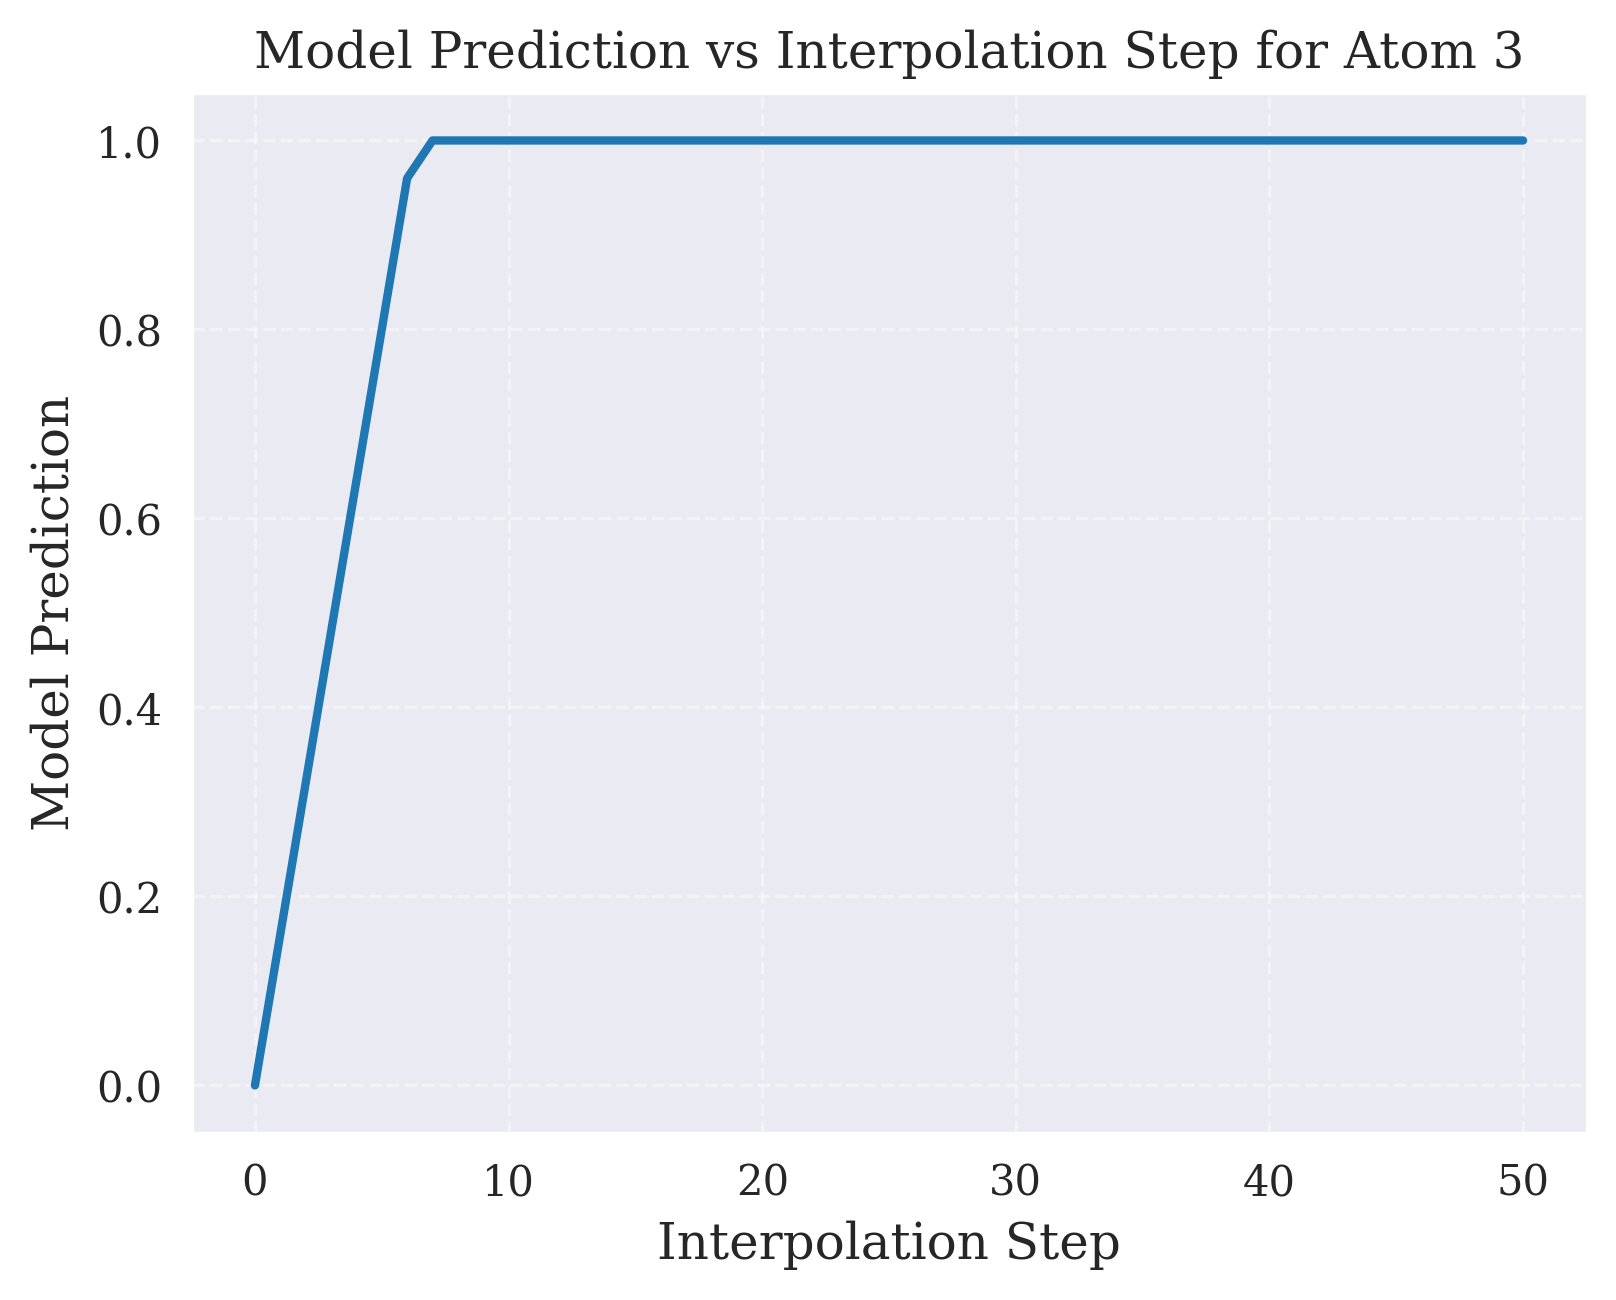

In [16]:
#x, edge_index, edge_features = mol_to_torch(mol)
model = MoleculeGDetector()

x_zerod_third_atom = x.clone()
x_zerod_third_atom[0][6] = 0

diff = x - x_zerod_third_atom

num_steps = 50
increment = diff / num_steps

predictions = []

for step in range(num_steps + 1):
    interpolated_x = x_zerod_third_atom + increment * step
    with torch.no_grad():
        pred = model(interpolated_x, edge_features, edge_index)
        predictions.append(pred.item())

plt.plot(predictions)
plt.xlabel("Interpolation Step")
plt.ylabel("Model Prediction")
plt.title("Model Prediction vs Interpolation Step for Atom 3")
plt.show()


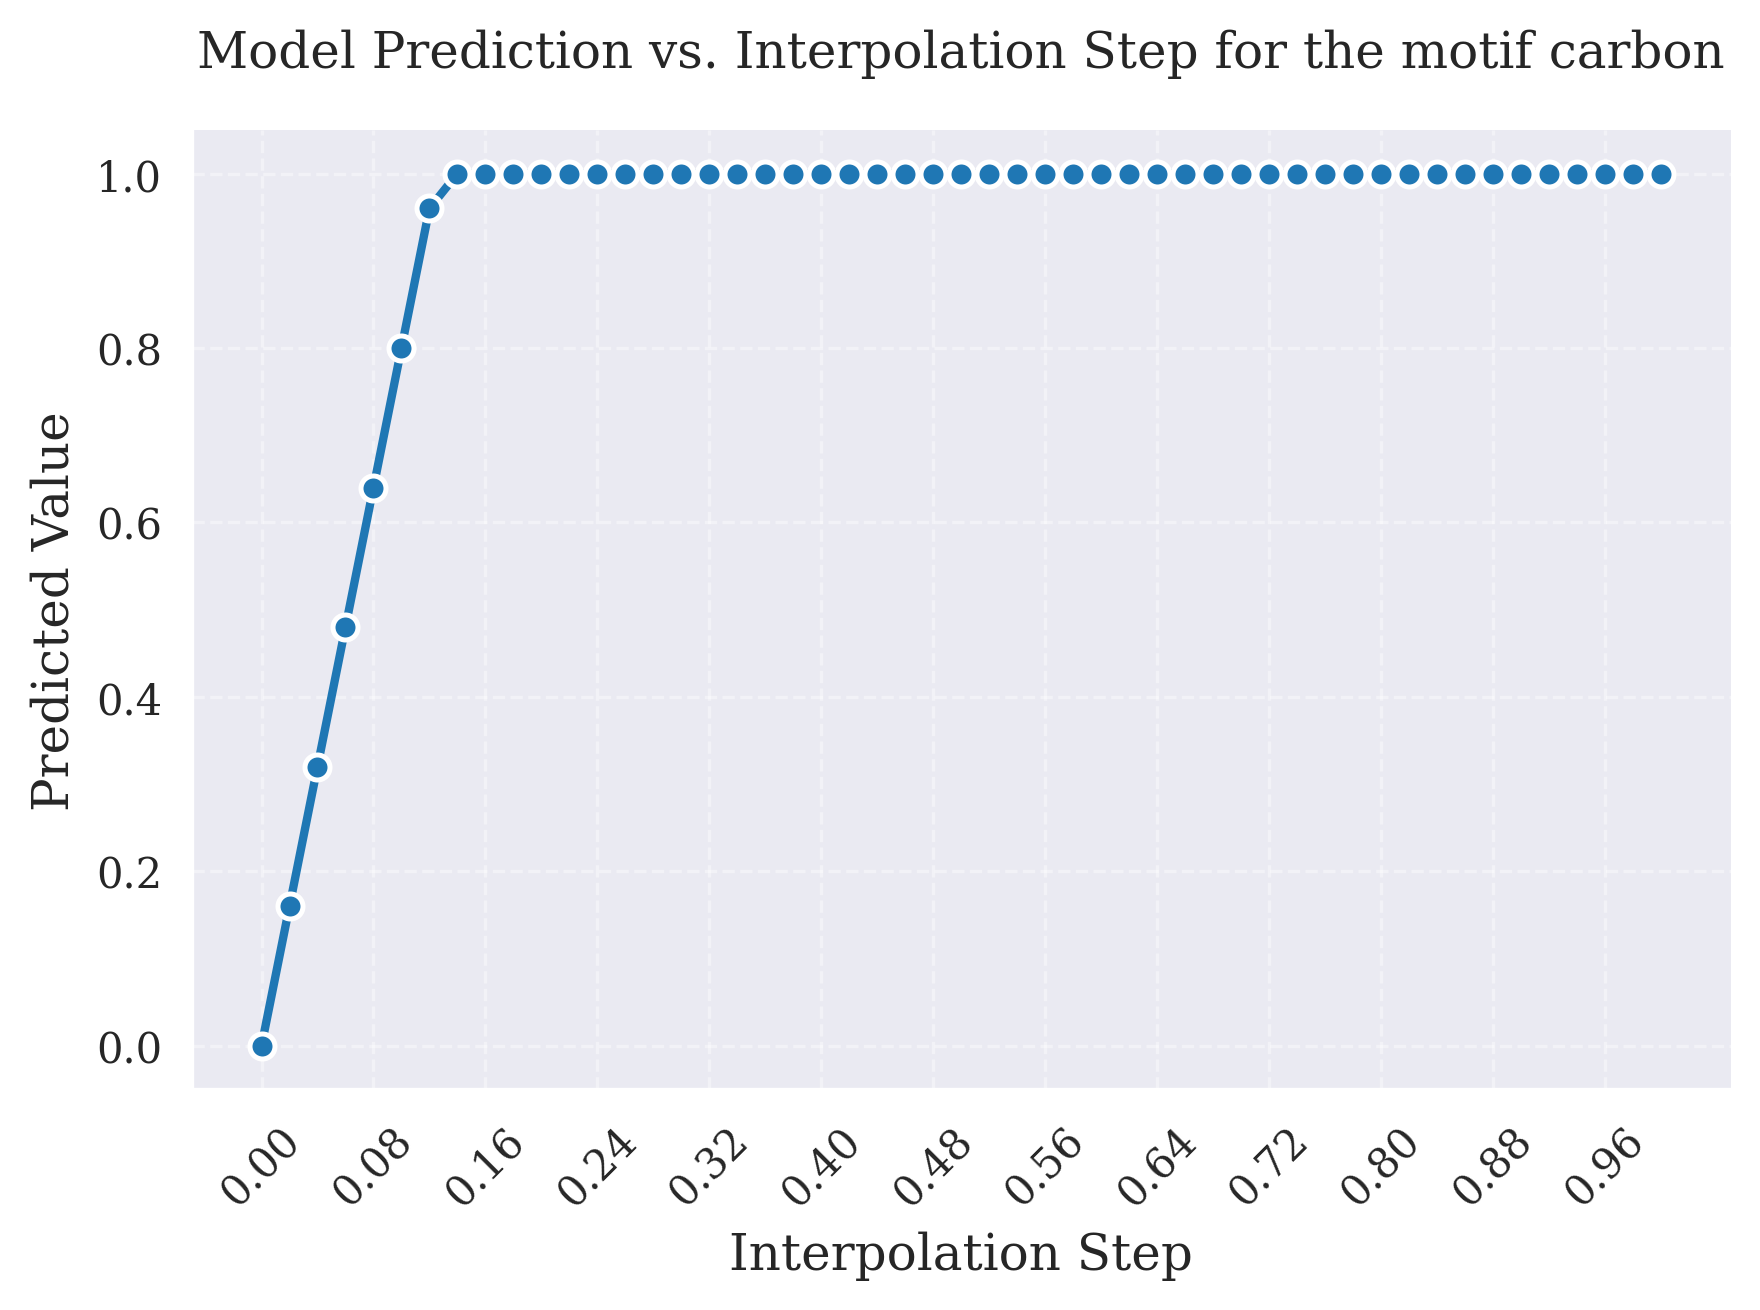

In [18]:
# This code for chart was styled with use of LLM; however, I've verified that it aligns with what I've done myself. (see cell above)

import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Publication-Ready Global Formatting
# ---------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (6, 4.5),  # Standard single-column size
    "figure.dpi": 300,  # High resolution for rendering
    "font.family": "serif",  # Typical academic font style
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,  # Readable base font size
    "axes.labelsize": 12,  # Slightly larger axis labels
    "axes.titlesize": 12,  # Title size
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,  # Thicker, bolder lines
    "lines.markersize": 6,  # Visible data points
    "axes.grid": True,  # Add grid for readability
    "grid.alpha": 0.4,  # Make grid unobtrusive
    "grid.linestyle": "--"  # Dashed grid lines
})

# [Assume mol_to_torch and model setup here]
# x, edge_index, edge_features = mol_to_torch(mol)
# model.readout = AllNonZeroReadout()

x_zerod_third_atom = x.clone()
x_zerod_third_atom[0][6] = 0.0  # Zero out the "carbon" feature

diff = x - x_zerod_third_atom

num_steps = 50
increment = diff / num_steps
scalar_increment = 1 / num_steps

xlabels = []
predictions = []

for step in range(num_steps + 1):
    xlabels.append(scalar_increment * step)
    interpolated_x = x_zerod_third_atom + increment * step
    with torch.no_grad():
        pred = model(interpolated_x, edge_features, edge_index)
        predictions.append(pred.item())

# ---------------------------------------------------------
# 2. Object-Oriented Plotting
# ---------------------------------------------------------
fig, ax = plt.subplots()

# Use a marker to explicitly show the discrete interpolation steps
ax.plot(range(num_steps + 1), predictions, color="#1f77b4", marker="o",
        markeredgecolor="white", markeredgewidth=1.2, label="Model Prediction")

# Format labels to 2 decimal places
xlabels_str = [f"{label:.2f}" for label in xlabels]

# To prevent crowding, optionally only show every 2nd or 4th tick label
# Here, we display every 4th tick for a cleaner X-axis
tick_spacing = 4
ax.set_xticks(range(0, num_steps + 1, tick_spacing))
ax.set_xticklabels(xlabels_str[::tick_spacing], rotation=45)

ax.set_xlabel("Interpolation Step")
ax.set_ylabel("Predicted Value")

# Note: Titles are often omitted in final papers in favor of figure captions.
# If you keep it, give it some padding so it doesn't overlap.
ax.set_title("Model Prediction vs. Interpolation Step for the motif carbon", pad=15)

# Remove top and right spines (borders) to reduce chart junk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# 3. Save as Vector Graphic and High-Res Raster
# ---------------------------------------------------------
plt.tight_layout()  # Ensures labels don't get cut off during save

# Save as PDF for the manuscript (infinite scalability)
plt.savefig("atom3_interpolation.pdf", format="pdf", bbox_inches="tight")
# Save as PNG for presentations or quick sharing
plt.savefig("atom3_interpolation.png", dpi=300, bbox_inches="tight")

plt.show()

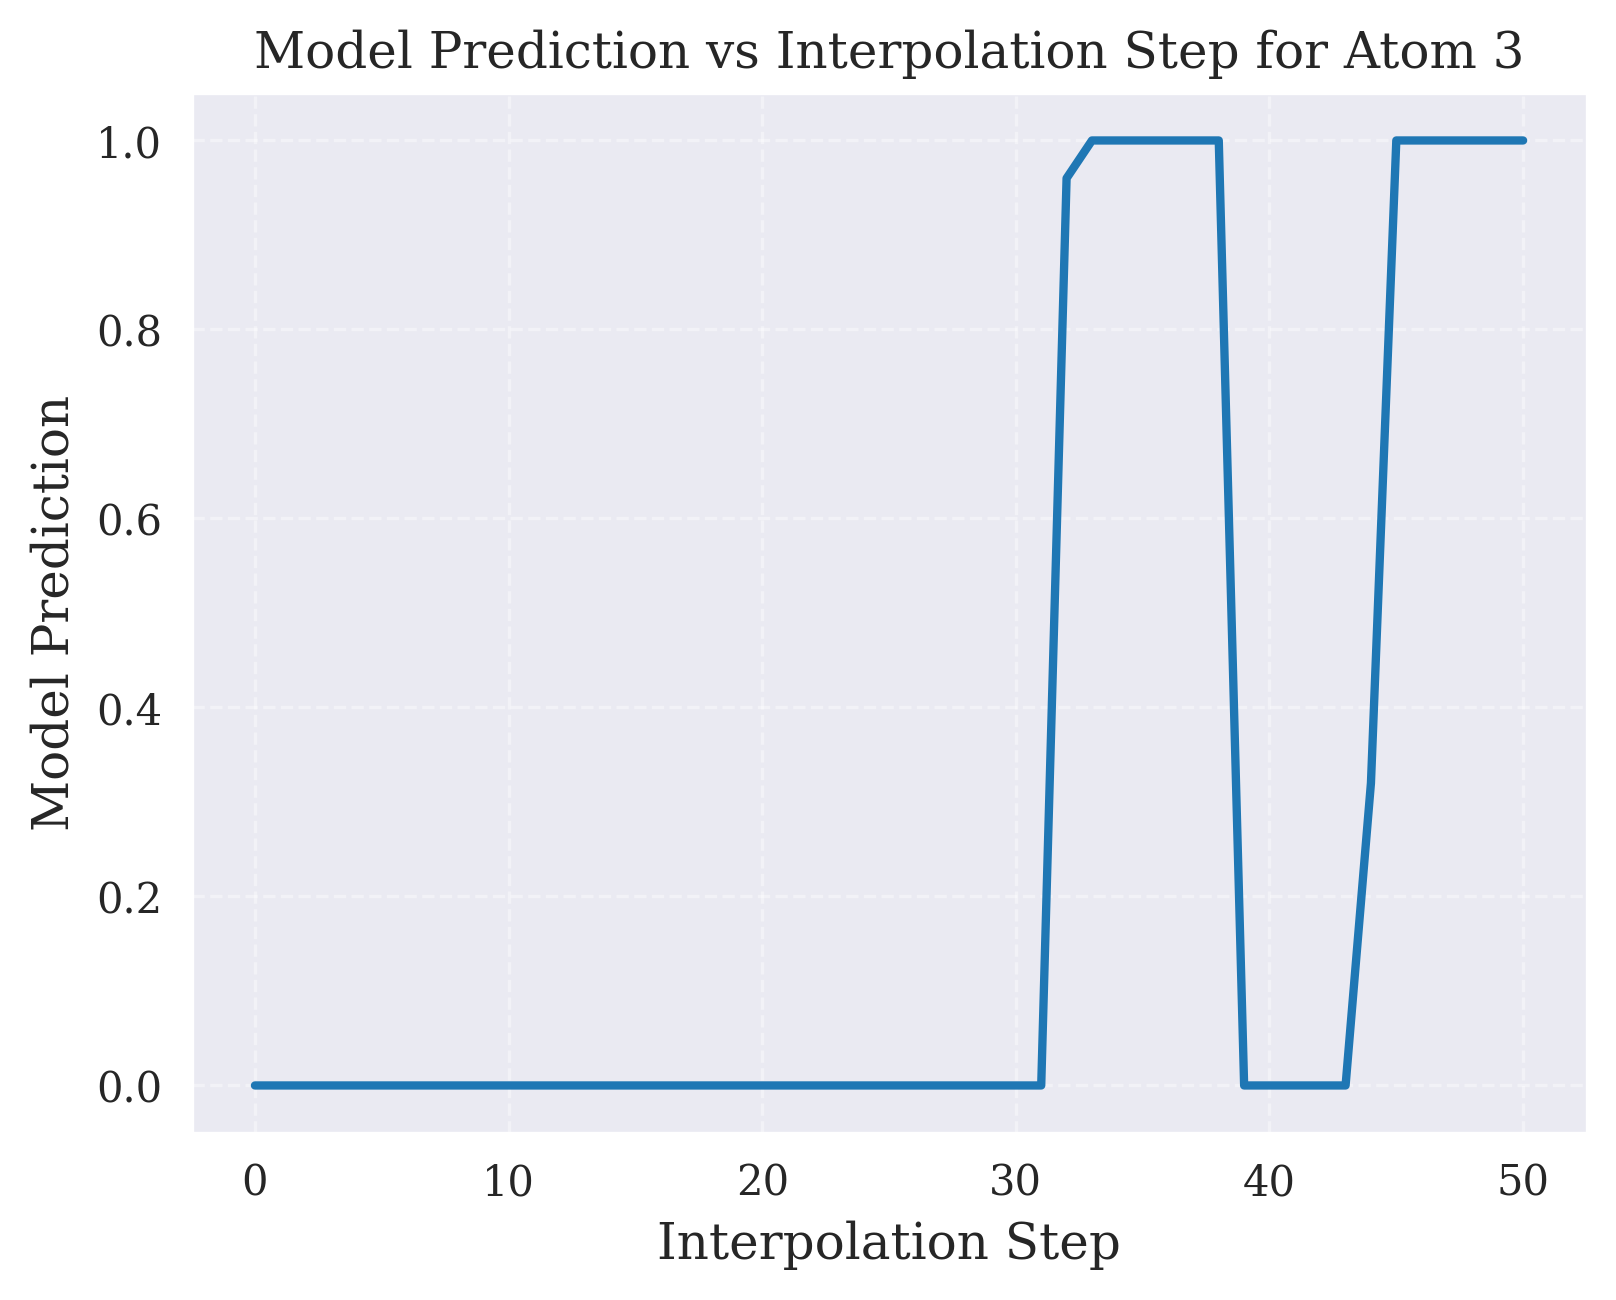

In [19]:
# See relative to atom 0

# As shown here, the problematic atom is atom 3. Now: Let's interpolate it from baseline (all 0's) to the actual value and see how the prediction changes.

#x, edge_index, edge_features = mol_to_torch(mol)

model.readout = AllNonZeroReadout()

x_zerod_zeroth_atom = x.clone()
x_zerod_zeroth_atom[2] = torch.zeros_like(x_zerod_zeroth_atom[2])

diff = x - x_zerod_zeroth_atom

num_steps = 50
increment = diff / num_steps

predictions = []

for step in range(num_steps + 1):
    interpolated_x = x_zerod_zeroth_atom + increment * step
    with torch.no_grad():
        pred = model(interpolated_x, edge_features, edge_index)
        predictions.append(pred.item())

plt.plot(predictions)
plt.xlabel("Interpolation Step")
plt.ylabel("Model Prediction")
plt.title("Model Prediction vs Interpolation Step for Atom 3")
plt.show()


/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/captum/attr/_utils/gradient.py:31: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/captum/attr/_utils/gradient.py:31: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


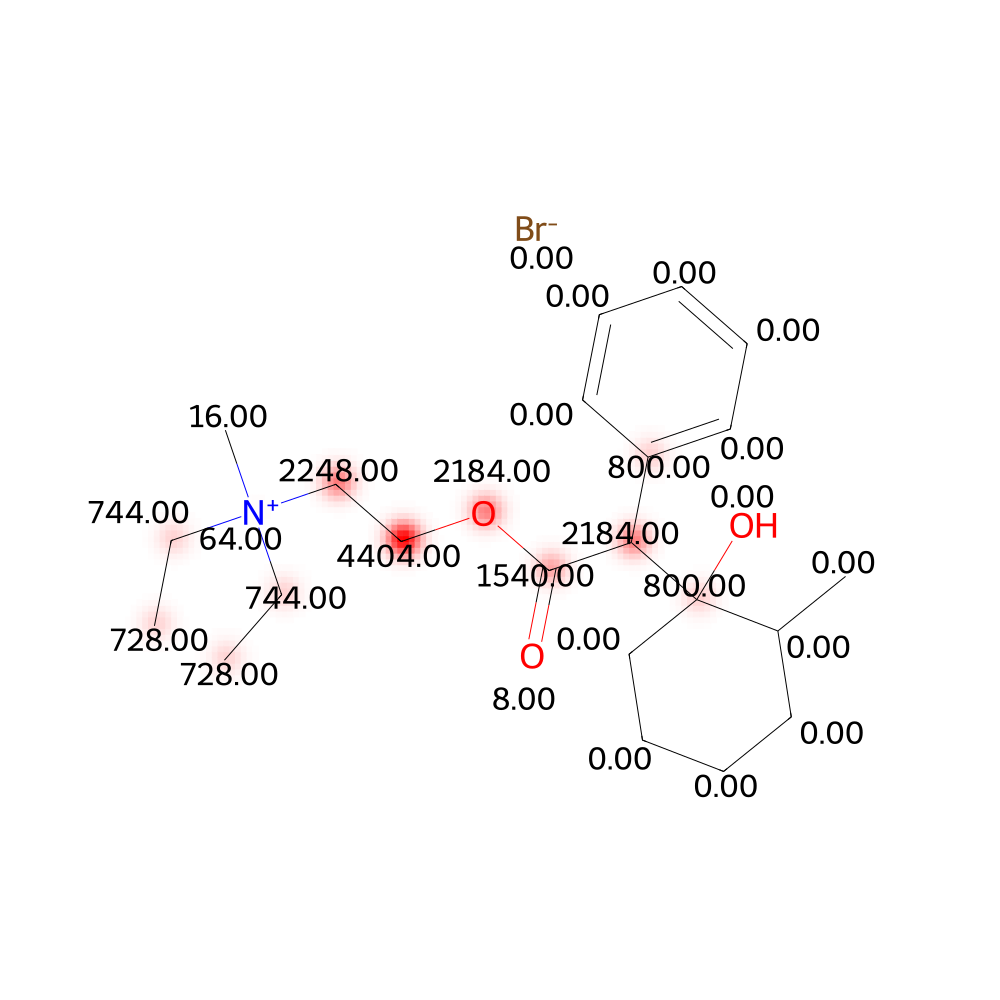

In [10]:

smarts_post = name_to_post_smarts["MoleculeGDetector"]

model.readout = AllNonZeroMaxReadout()

ig_explainer = SaliencyAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)

img

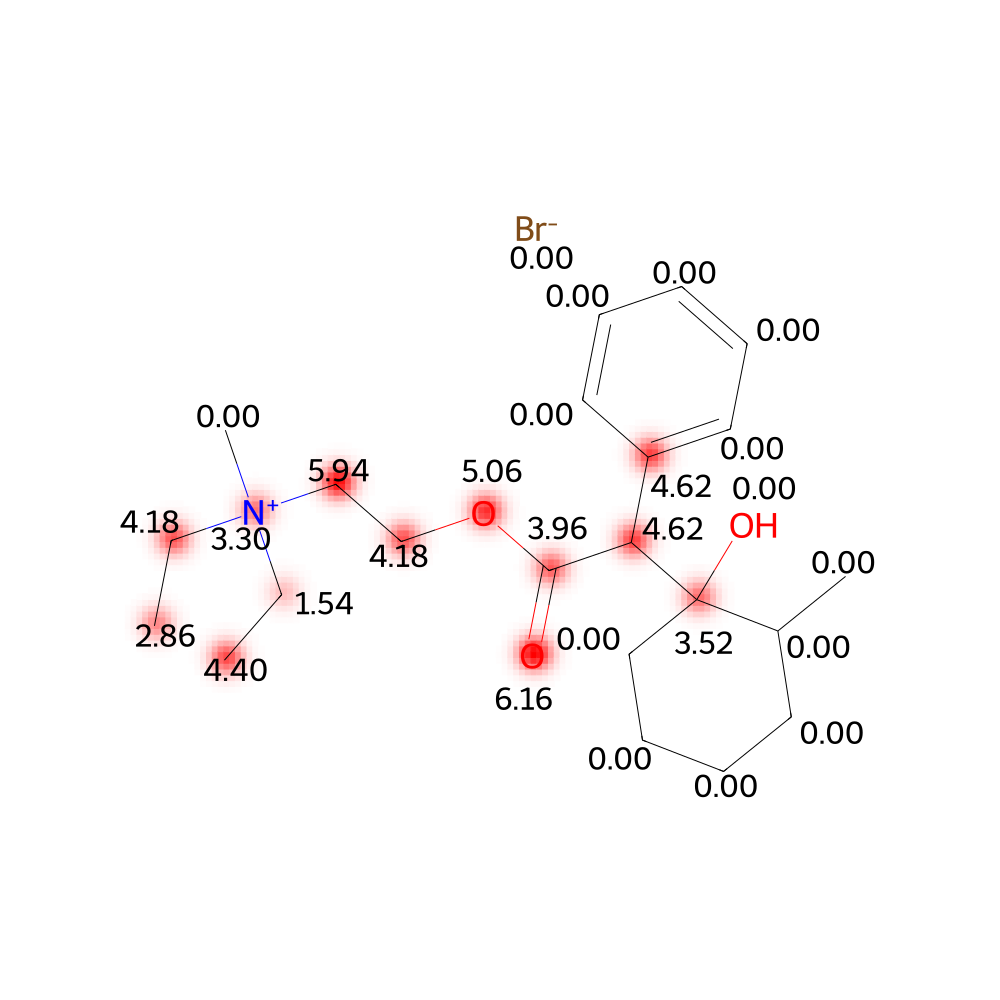

In [11]:

smarts_post = name_to_post_smarts["MoleculeGDetector"]

model.readout = AllNonZeroReadout()

ig_explainer = ShapleyValueSamplingAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    n_samples=500,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)

img

In [12]:
df = pd.read_csv(
    "artifacts/explainability_method_tester/20260501_115658/MoleculeGDetector/positive_explainability_results.csv")

df = df[df["Saliency_auroc"] != 1.0]

saliency_failing_smiles = df["SMILES"].dropna().tolist()

df = pd.read_csv(
    "artifacts/explainability_method_tester/20260429_221014/MoleculeGDetector/positive_explainability_results.csv")

df = df[df["Integrated Gradients_auroc"] != 1.0]
ig_failing_smiles = df["SMILES"].dropna().tolist()

saliency_failing_smiles = set(saliency_failing_smiles)
ig_failing_smiles = set(ig_failing_smiles)

both_failing_smiles = saliency_failing_smiles.intersection(ig_failing_smiles)

only_saliency_failing_smiles = saliency_failing_smiles - both_failing_smiles

only_ig_failing_smiles = ig_failing_smiles - both_failing_smiles

print("Number of SMILES where both IG and Saliency fail:", len(both_failing_smiles))
print("Number of SMILES where only Saliency fails:", len(only_saliency_failing_smiles))
print("Number of SMILES where only IG fails:", len(only_ig_failing_smiles))

Number of SMILES where both IG and Saliency fail: 182
Number of SMILES where only Saliency fails: 52
Number of SMILES where only IG fails: 0


In [13]:
assert suspicious_smiles[
           0] in both_failing_smiles, "The example suspicious smile should be in the set of SMILES where both IG and Saliency fail."

In [14]:
# Question: Is there any case where IG fails but Saliency doesn't?
import pathlib

readout_1_directory = pathlib.Path("artifacts/explainability_method_tester/20260501_115658")
readout_2_directory = pathlib.Path("artifacts/explainability_method_tester/20260429_221014")

subfolders_readout_1 = [f.name for f in readout_1_directory.iterdir() if f.is_dir()]
subfolders_readout_2 = [f.name for f in readout_2_directory.iterdir() if f.is_dir()]

subfolders_readout_1 = sorted(subfolders_readout_1)
subfolders_readout_2 = sorted(subfolders_readout_2)

assert subfolders_readout_1 == subfolders_readout_2, "The subfolder names (which correspond to model names) should be the same in both directories."

for i, subdir_name in enumerate(subfolders_readout_1):
    print(f"For model {i} {subdir_name}:")

readout_1_csv = readout_1_directory / subdir_name / "positive_explainability_results.csv"
readout_2_csv = readout_2_directory / subdir_name / "positive_explainability_results.csv"

df_readout_1 = pd.read_csv(readout_1_csv)
df_readout_2 = pd.read_csv(readout_2_csv)

df_readout_1 = df_readout_1[df_readout_1["Saliency_auroc"] != 1.0]
df_readout_2 = df_readout_2[df_readout_2["Integrated Gradients_auroc"] != 1.0]

saliency_failing_smiles = set(df_readout_1["SMILES"].dropna().tolist())
ig_failing_smiles = set(df_readout_2["SMILES"].dropna().tolist())

only_saliency_failing_smiles = saliency_failing_smiles - ig_failing_smiles
only_ig_failing_smiles = ig_failing_smiles - saliency_failing_smiles

print("Number of SMILES where only Saliency fails:", len(only_saliency_failing_smiles))
print("Number of SMILES where only IG fails:", len(only_ig_failing_smiles))

if len(only_ig_failing_smiles) > 0:
    print("SMILES where only IG fails:", only_ig_failing_smiles)

For model 0 MoleculeCDetector:
For model 1 MoleculeEDetector:
For model 2 MoleculeFDetector:
For model 3 MoleculeGDetector:
For model 4 MoleculeHDetector:
For model 5 MoleculeIDetector:
For model 6 MoleculeJDetector:
For model 7 MoleculeKDetector:
For model 8 MoleculeLDetector:
For model 9 MoleculeMDetector:
For model 10 MoleculeNDetector:
For model 11 MoleculeODetector:
For model 12 MoleculePDetector:
For model 13 MoleculeQDetector:
Number of SMILES where only Saliency fails: 787
Number of SMILES where only IG fails: 0


Atom importance before abs tensor(0.7590, dtype=torch.float64)
Edge importance before abs tensor(0.5429, dtype=torch.float64)
Model prediction: 1.0
Total sum of absolute atom importance values: 0.7589824175182935


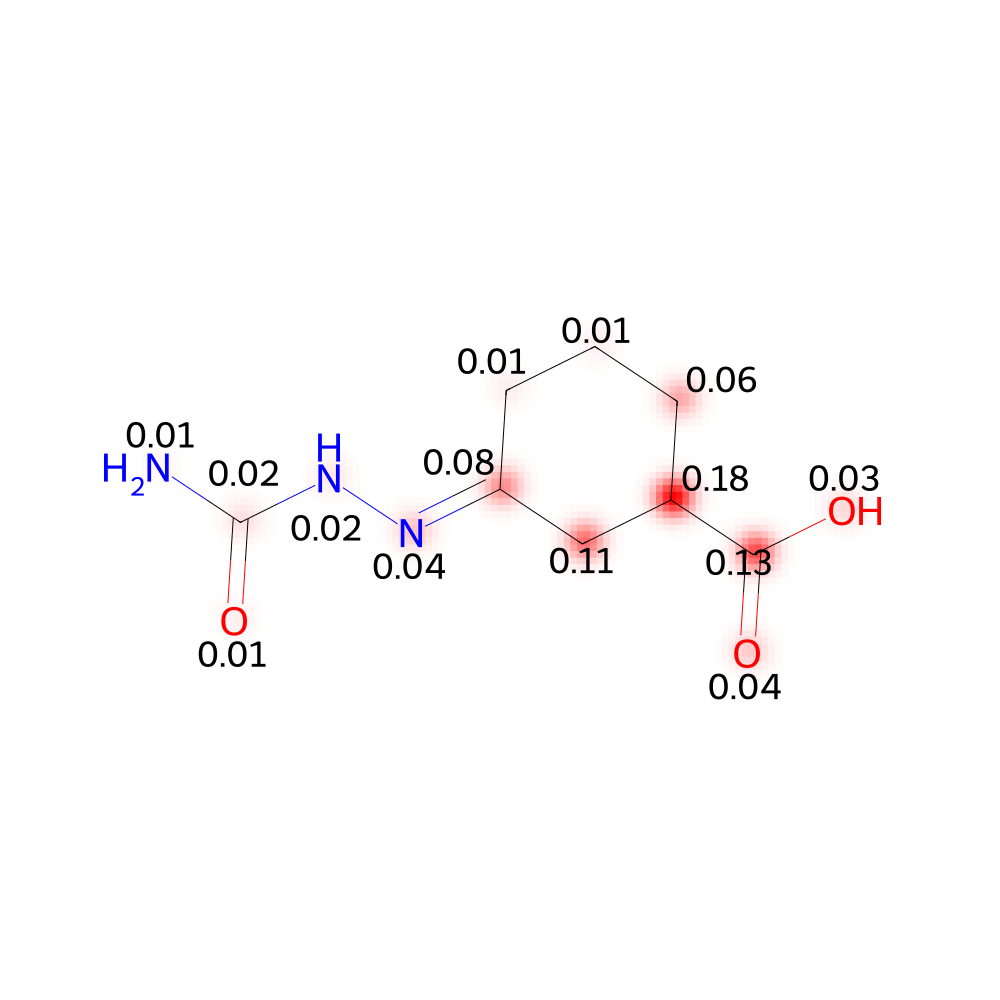

In [15]:
from mpnn import MoleculeHDetector

ultimately_suspicious_smiles = "NC(=O)NN=C1CCCC(C(=O)O)C1"

mol = Chem.MolFromSmiles(ultimately_suspicious_smiles)
mol = Chem.RemoveAllHs(mol)

x, edge_index, edge_features = mol_to_torch(mol)

smarts_post = name_to_post_smarts["MoleculeHDetector"]
model = MoleculeHDetector()
model.readout = AllNonZeroReadout()

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, edge_importance = ig_explainer.explain(x, edge_features, edge_index)

print("Atom importance before abs", torch.sum(atom_importance))
print("Edge importance before abs", torch.sum(edge_importance))

print("Model prediction:", model(x, edge_features, edge_index).item())

atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)

total_sum = sum(atom_importance)
print("Total sum of absolute atom importance values:", total_sum)

img

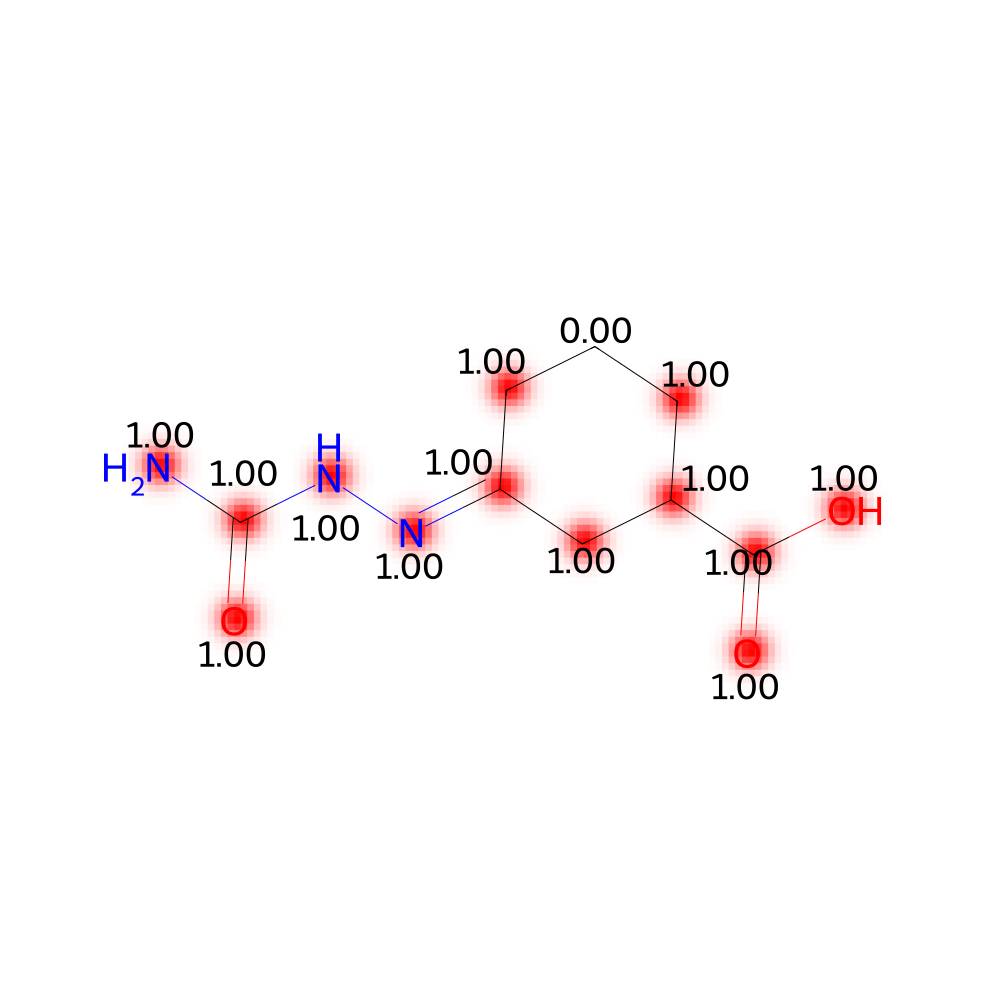

In [16]:
baseline_img = visualize_smarts_match(
    mol,
    smarts_post,
)

baseline_img


In [ ]:
# Gotta get atom ids

for atom in mol.GetAtoms():
    atom.SetProp('atomNote', f"{atom.GetIdx()}")

Draw.MolToImage(mol, size=(1000, 1000))

Numerically different elements in predictions: 1


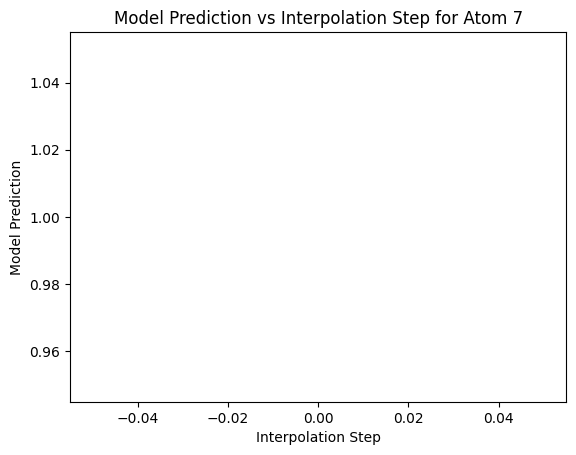

In [18]:
# Let's check what's going on with atom 7
model = MoleculeHDetector()
#model.readout = AllNonZeroMaxReadout()
x_zerod_seventh_atom = x.clone()
x_zerod_seventh_atom[7] = torch.zeros_like(x_zerod_seventh_atom[7])
diff = x - x_zerod_seventh_atom

num_steps = 10000
increment = diff / num_steps

predictions = []

for step in range(num_steps + 1):
    interpolated_x = x_zerod_seventh_atom + increment * step
with torch.no_grad():
    pred = model(interpolated_x, edge_features, edge_index)
predictions.append(pred.item())

plt.plot(predictions)
plt.xlabel("Interpolation Step")
plt.ylabel("Model Prediction")
plt.title("Model Prediction vs Interpolation Step for Atom 7")

numerically_different_elements = set(predictions)

print("Numerically different elements in predictions:", len(numerically_different_elements))

plt.show()

/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/captum/attr/_utils/gradient.py:31: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/captum/attr/_utils/gradient.py:31: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


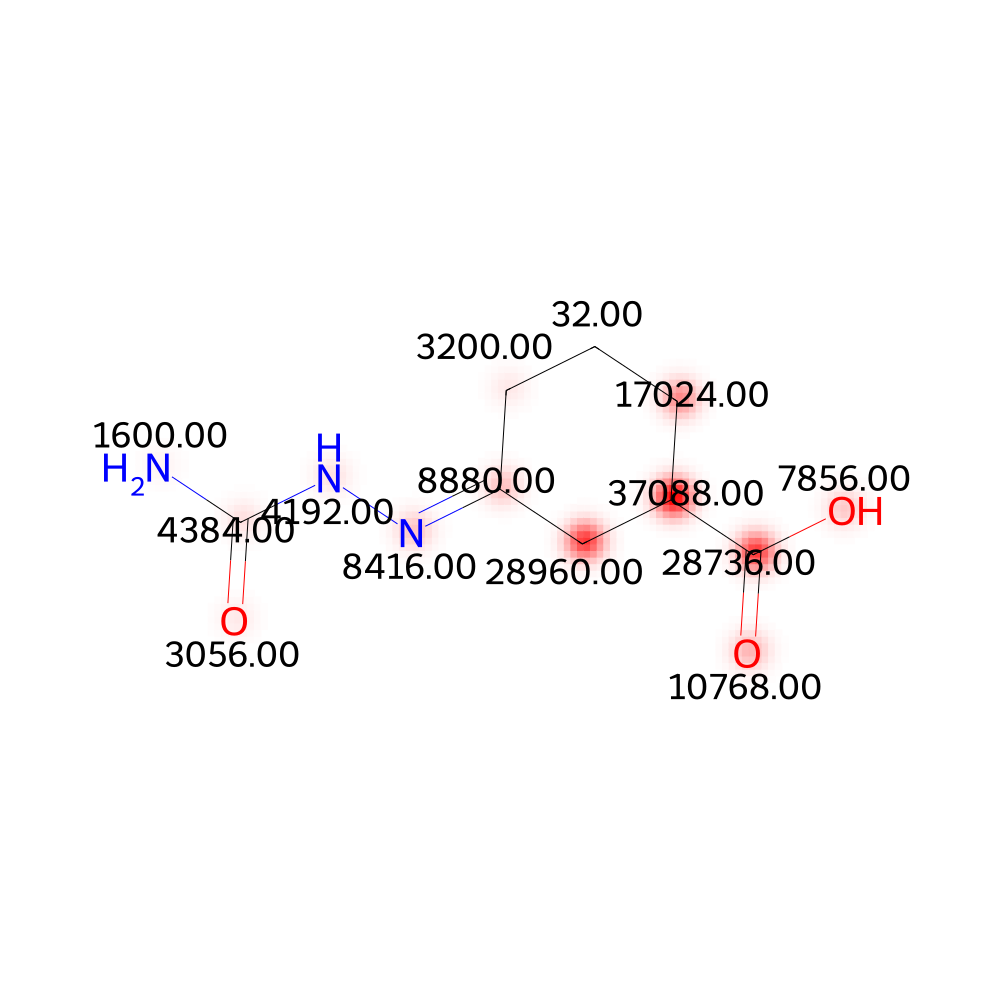

In [19]:
# What's going on with you, Saliency?
model.readout = AllNonZeroMaxReadout()

saliency_explainer = SaliencyAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = saliency_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000
)
img

Numerically different elements in predictions: 1


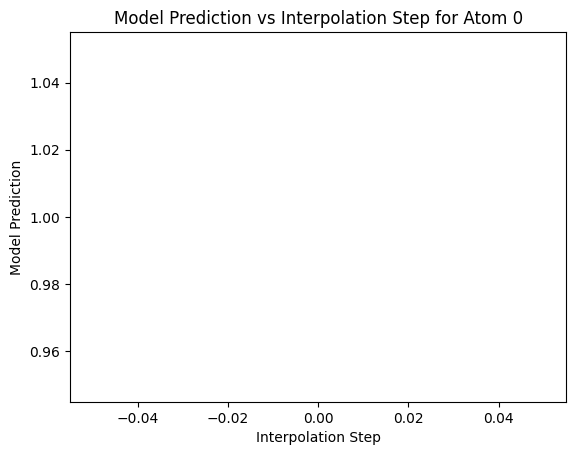

In [20]:
# And check out atom 0 which gets smaller attribution value than atom 7
x_zerod_zeroth_atom = x.clone()
x_zerod_zeroth_atom[0] = torch.zeros_like(x_zerod_zeroth_atom[0])
diff = x - x_zerod_zeroth_atom
num_steps = 10000
increment = diff / num_steps

predictions = []

model = MoleculeHDetector()

for step in range(num_steps + 1):
    interpolated_x = x_zerod_zeroth_atom + increment * step
with torch.no_grad():
    pred = model(interpolated_x, edge_features, edge_index)
predictions.append(pred.item())

plt.plot(predictions)
plt.xlabel("Interpolation Step")
plt.ylabel("Model Prediction")
plt.title("Model Prediction vs Interpolation Step for Atom 0")
numerically_different_elements = set(predictions)

print("Numerically different elements in predictions:", len(numerically_different_elements))
plt.show()